# German Electricity Price Forecast - hourly 

## EDA - Price vs Time
* fetch data from SMARD API and save to SQLite database automatically with ETL pipeline
    - Scrape prices and other data from SMARD
    - Ingest into SQLite DB
* Load data and EDA

In [2]:
import sys
import os

# Add the src directory to the system path to allow importing custom modules
project_root = os.path.abspath("..")
src_dir = os.path.join(project_root, "src")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import pandas as pd

from etl_price import *
#from fetch_prepare_data_price import *
from train_model_predict import *

# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})


## Prepare raw data

* update database 
    - check data status
    - fetch data from SMARD
    - ingest into database
* tables 
    - data_quality_log:
        - ['id', 'run_id', 'series_id', 'check_name', 'result', 'details', 'checked_at']
    - energy_demand:
        - ['time', 'energy_demand_mwh', 'smard_forecast_mwh', 'data_source', 'year', 'hour', 'weekday', 'month', 'is_weekend', 'is_holiday', 'holiday_ratio', 'is_workday', 'is_bridge_day', 'holiday_weight', 'is_pandemic_time', 'energy_demand_lag_24h', 'energy_demand_lag_168h', 'energy_demand_rolling_mean_24h', 'energy_demand_rolling_mean_168h']
    - ingestion_runs:
        - ['run_id', 'start_ts', 'end_ts', 'status', 'source', 'rows_loaded', 'error_text']
    - series_catalog:
        - ['series_id', 'source', 'filter_id', 'region', 'resolution', 'unit', 'active', 'description', 'created_at', 'updated_at']
    - timeseries_values:
        - ['time', 'series_id', 'value', 'data_source', 'fetched_at', 'version']
    - weather:
        - ['time', 'apparent_temperature', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'apparent_temperature_lag_24h', 'apparent_temperature_rolling_mean_24h', 'shortwave_radiation_0m_lag_24h', 'shortwave_radiation_0m_rolling_mean_24h', 'heating_degree', 'cooling_degree']
* series_id:
    - ['price_de_lu_eur_mwh', 'gen_wind_onshore_mwh', 'gen_wind_offshore_mwh', 'gen_pv_mwh', 'gen_other_conventional_mwh']

In [ ]:
import sqlite3

conn = sqlite3.connect("../db/energy_demand.db")
cur = conn.cursor()

# Rename the column "time_utc" to "time" in the "timeseries_values" table
cur.execute("ALTER TABLE timeseries_values RENAME COLUMN time_utc TO time;")
conn.commit()
conn.close()

In [31]:
# update database with new data
import sqlalchemy as sa
from etl_price import update_database

#update_database(start_date='2019-01-01', end_date='2026-05-27')

engine = sa.create_engine('sqlite:///../db/energy_demand.db')
inpector = sa.inspect(engine)
table_names = inpector.get_table_names()
for table in table_names:
    print(f"Columns in {table}:\n {[col['name'] for col in inpector.get_columns(table)]}")

Columns in data_quality_log:
 ['id', 'run_id', 'series_id', 'check_name', 'result', 'details', 'checked_at']
Columns in energy_demand:
 ['time', 'energy_demand_mwh', 'smard_forecast_mwh', 'data_source', 'year', 'hour', 'weekday', 'month', 'is_weekend', 'is_holiday', 'holiday_ratio', 'is_workday', 'is_bridge_day', 'holiday_weight', 'is_pandemic_time', 'energy_demand_lag_24h', 'energy_demand_lag_168h', 'energy_demand_rolling_mean_24h', 'energy_demand_rolling_mean_168h']
Columns in ingestion_runs:
 ['run_id', 'start_ts', 'end_ts', 'status', 'source', 'rows_loaded', 'error_text']
Columns in series_catalog:
 ['series_id', 'source', 'filter_id', 'region', 'resolution', 'unit', 'active', 'description', 'created_at', 'updated_at']
Columns in timeseries_values:
 ['time', 'series_id', 'value', 'data_source', 'fetched_at', 'version']
Columns in weather:
 ['time', 'apparent_temperature', 'rain', 'snowfall', 'wind_speed_10m', 'shortwave_radiation', 'apparent_temperature_lag_24h', 'apparent_temperat

## Check the structure, data types and values

* Load data from db
* check info, describe

In [2]:
import sqlalchemy as sa
import pandas as pd

engine = sa.create_engine('sqlite:///../db/energy_demand.db')
query_price_gen = "SELECT * FROM timeseries_values"
df_price_gen = pd.read_sql(query_price_gen, engine)
df_price_gen['time'] = pd.to_datetime(df_price_gen['time'], utc=True)

# Pivot the DataFrame to have 'time' as the index and 'series_id' as columns
df_price_gen = df_price_gen.pivot(index='time', columns='series_id', values='value')


In [ ]:
display(df_price_gen.info())
print(df_price_gen['series_id'].unique())

print('\nprice describe:')
display(df_price_gen[df_price_gen['series_id'] == 'price_de_lu_eur_mwh']['value'].describe())
print('\nwind onshore generation describe:')
display(df_price_gen[df_price_gen['series_id'] == 'gen_wind_onshore_mwh']['value'].describe())
print('\nwind offshore generation describe:')
display(df_price_gen[df_price_gen['series_id'] == 'gen_wind_offshore_mwh']['value'].describe())
print('\nsolar generation describe:')
display(df_price_gen[df_price_gen['series_id'] == 'gen_pv_mwh']['value'].describe())
print('\nother generation describe:')
display(df_price_gen[df_price_gen['series_id'] == 'gen_other_conventional_mwh']['value'].describe())


<class 'pandas.DataFrame'>
RangeIndex: 324559 entries, 0 to 324558
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype              
---  ------       --------------   -----              
 0   time_utc     324559 non-null  datetime64[us, UTC]
 1   series_id    324559 non-null  str                
 2   value        324559 non-null  float64            
 3   data_source  324559 non-null  str                
 4   fetched_at   324559 non-null  str                
 5   version      324559 non-null  int64              
dtypes: datetime64[us, UTC](1), float64(1), int64(1), str(3)
memory usage: 29.5 MB


None

<ArrowStringArray>
[       'price_de_lu_eur_mwh',       'gen_wind_onshore_mwh',
      'gen_wind_offshore_mwh',                 'gen_pv_mwh',
 'gen_other_conventional_mwh']
Length: 5, dtype: str

price describe:


count    64919.000000
mean        94.846879
std         92.122842
min       -500.000000
25%         38.230000
50%         76.840000
75%        116.315000
max        936.280000
Name: value, dtype: float64


wind onshore generation describe:


...

count    64910.000000
mean      2902.182252
std       1968.044556
min          0.000000
25%       1110.535000
50%       2689.750000
75%       4587.750000
max       8448.340000
Name: value, dtype: float64


solar generation describe:


count    64910.000000
mean      6360.223048
std       9982.741858
min          0.000000
25%          3.000000
50%        188.000000
75%       9920.892500
max      56071.650000
Name: value, dtype: float64


other generation describe:


count    64910.000000
mean      1594.411127
std        266.964484
min        530.750000
25%       1415.750000
50%       1577.750000
75%       1789.750000
max       2669.500000
Name: value, dtype: float64

## Plot price and generation value distribution in histogram

* seemingly outliers in price present. 
* The other conventional generation has similiar distribution as price, can be used as reference for outlier identification/regression with RANSAC
* The negative prices concentrate in May since 2023. A time feature candidate.
* RANSAC with residual_thredshold=700 finds outliers concentrate on two time slots too

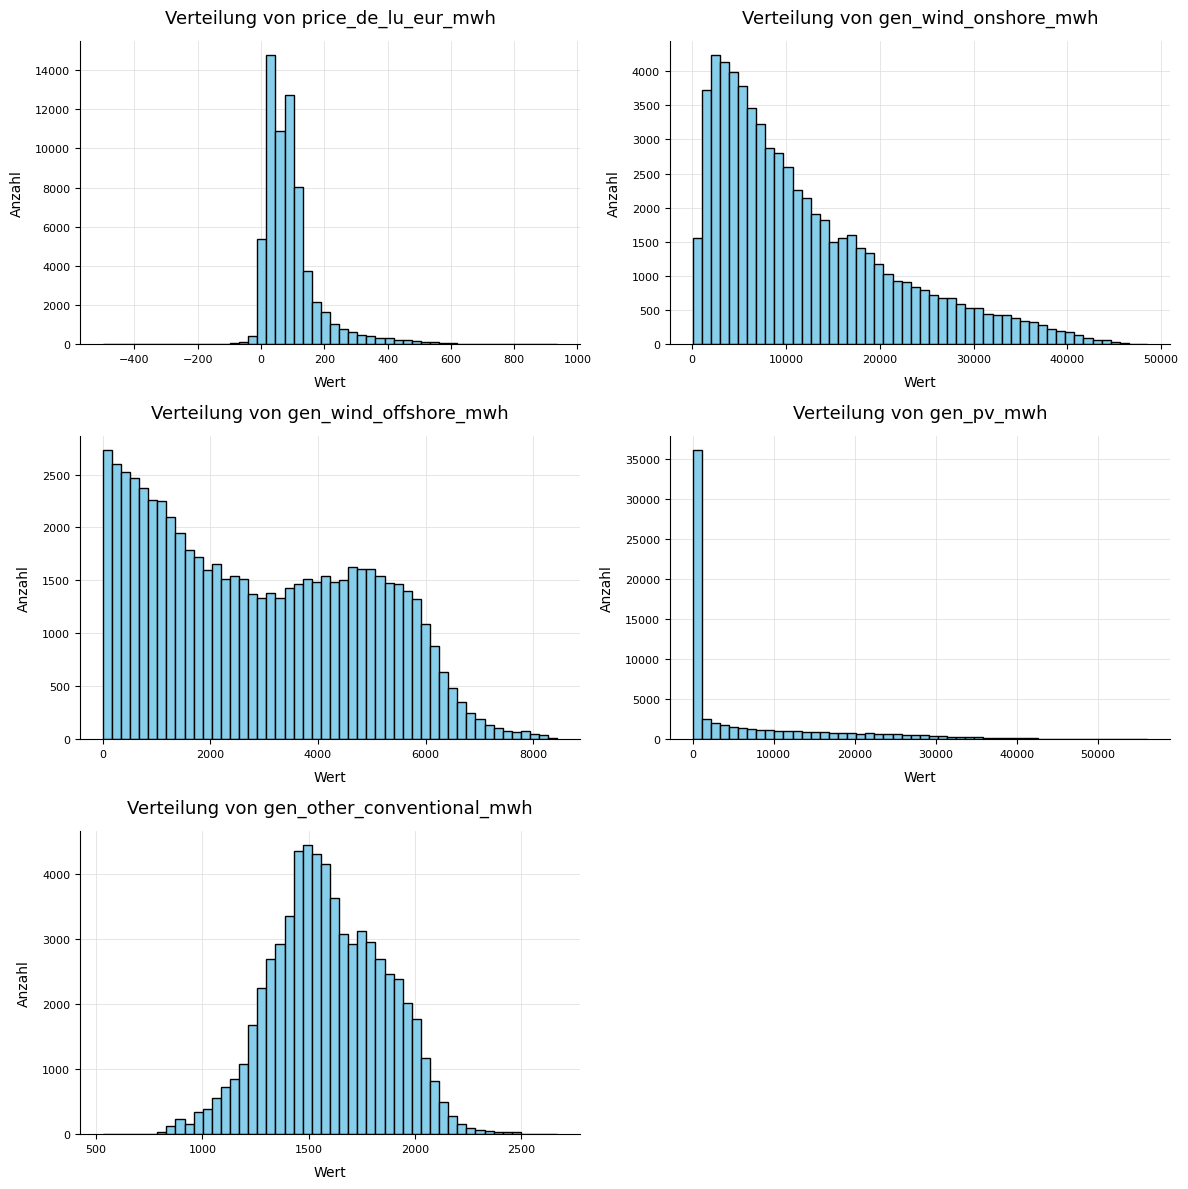

In [35]:
# Plot histogram of the price and energy generation values
from fetch_prepare_data_price import normalize_time_column
#df_price_min = normalize_time_column(df_price, col="time_utc", freq="min")  # für Minuten
df_hour = normalize_time_column(df_price_gen, col="time", freq="h")    # für Stunden

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()
for i, series_id in enumerate(df_hour['series_id'].unique()):
    ax = axes[i]
    df_subset = df_hour[df_hour['series_id'] == series_id]
    ax.hist(df_subset['value'], bins=50, color='skyblue', edgecolor='black')
    ax.set_title(f'Verteilung von {series_id}')
    ax.set_xlabel('Wert')
    ax.set_ylabel('Anzahl')

axes[5].axis('off')  # Hide the unused subplot
plt.tight_layout()
plt.show()


## 

## Price and generation value on time series

* Solar generation and price are negative correlated
* Surprisingly wind onshore and offshore and price have seemingly timely shifted correlation

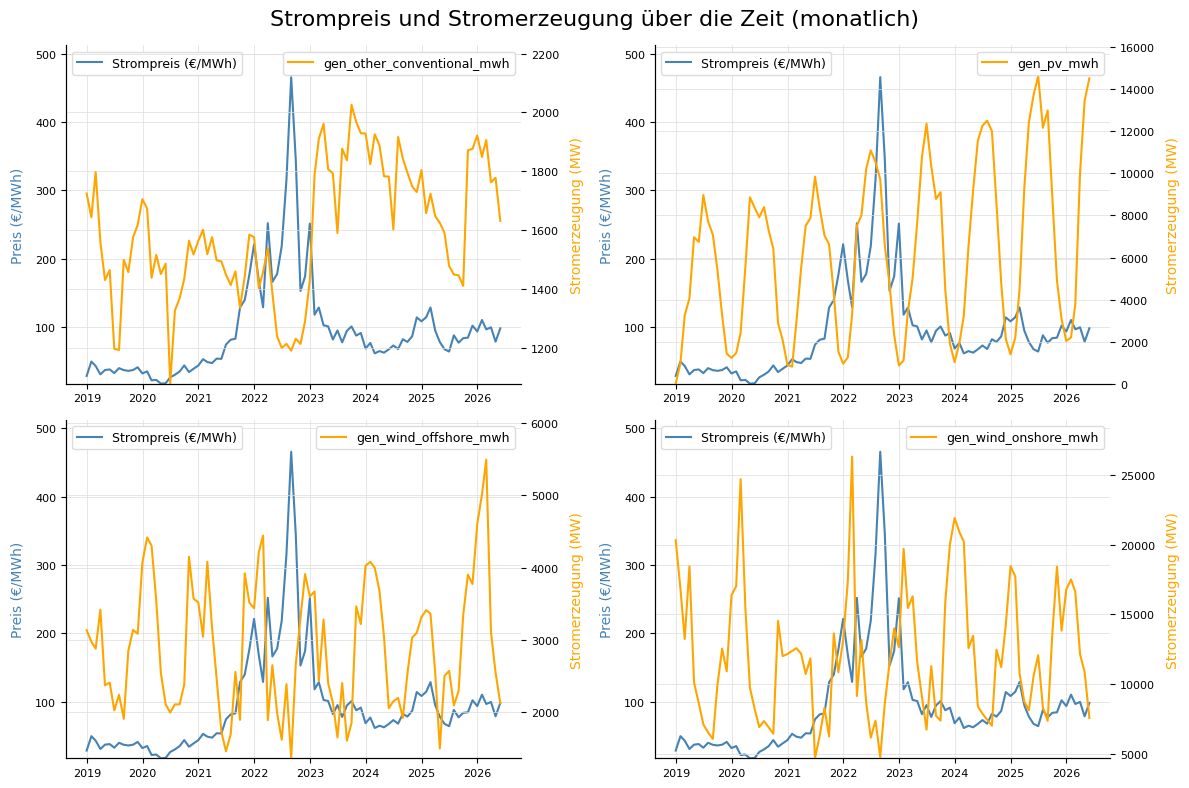

In [50]:
from fetch_prepare_data_price import normalize_time_column
# resample the data to monthly frequency by taking the mean value for each month    
df_monthly = (
    df_price_gen
    .groupby('series_id')
    .resample('ME', on='time')
    .mean(numeric_only=True)
    .reset_index()
)   # für Monate

mask_price = df_monthly['series_id'] == 'price_de_lu_eur_mwh'

df_monthly_price = df_monthly[df_monthly['series_id'] == 'price_de_lu_eur_mwh']
df_monthly_gen = df_monthly[~mask_price]

df_monthly_wind_onshore = df_monthly_gen[df_monthly_gen['series_id'] == 'gen_wind_onshore_mwh']
df_monthly_wind_offshore = df_monthly_gen[df_monthly_gen['series_id'] == 'gen_wind_offshore_mwh']
df_monthly_solar = df_monthly_gen[df_monthly_gen['series_id'] == 'gen_pv_mwh']
df_monthly_other = df_monthly_gen[df_monthly_gen['series_id'] == 'gen_other_conventional_mwh']

# plot the time series of the price and energy generation values each in one plot using twinx
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
for i, (series_id, df_series) in enumerate(df_monthly_gen.groupby('series_id')):
    ax[i].plot(df_monthly_price['time'], df_monthly_price['value'], label='Strompreis (€/MWh)', color='steelblue')
    ax_twinx = ax[i].twinx()
    ax_twinx.plot(df_series['time'], df_series['value'], color='orange', label=series_id)
    
    ax[i].set_ylabel('Preis (€/MWh)', color='steelblue')
    ax_twinx.set_ylabel('Stromerzeugung (MW)', color='orange')
    ax[i].legend(loc='upper left')
    ax_twinx.legend(loc='upper right')
    ax[i].set_ylim(df_monthly_price['value'].min(), df_monthly_price['value'].max() * 1.1)
    ax_twinx.set_ylim(df_series['value'].min(), df_series['value'].max() * 1.1)
plt.suptitle('Strompreis und Stromerzeugung über die Zeit (monatlich)', fontsize=16)
plt.tight_layout()
plt.show()


### Correlation in scatter plot
* confirms the impression of correlationship in the previous plots

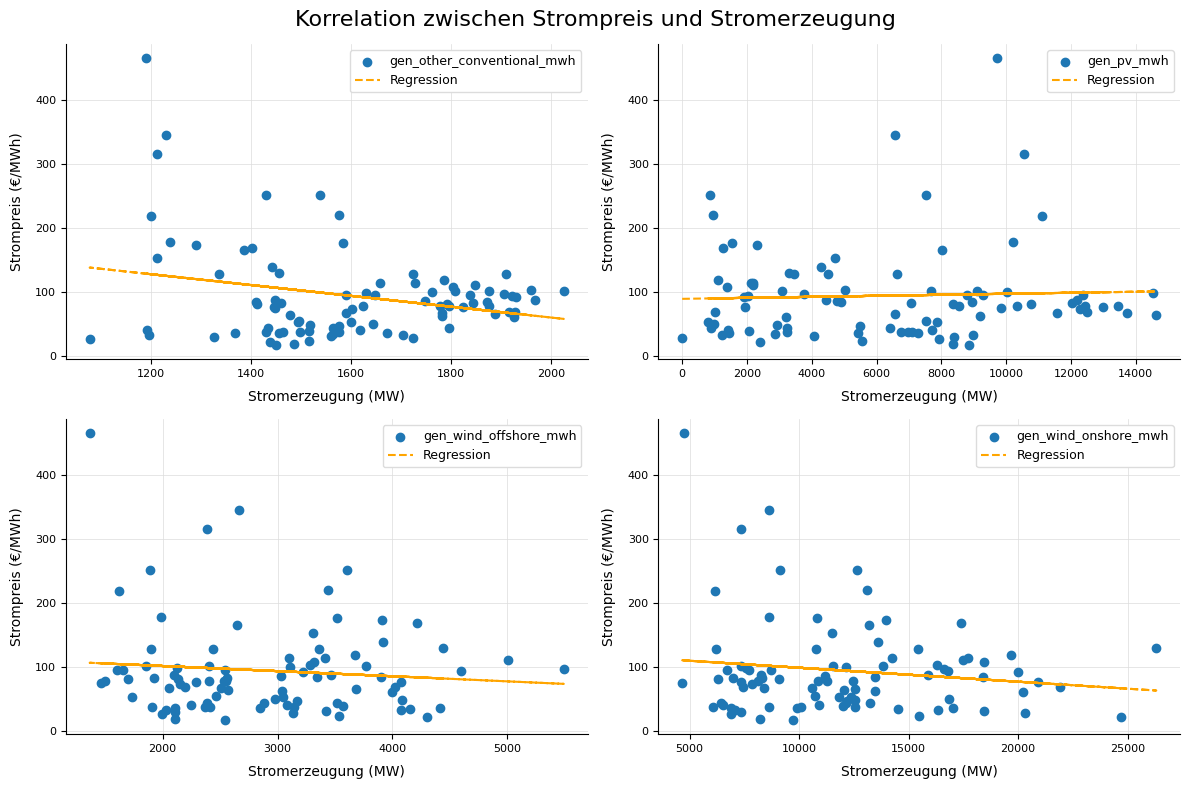

In [54]:
# plot correlation and regression between price and generation values using scatter plot
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
for i, (series_id, df_series) in enumerate(df_monthly_gen.groupby('series_id')):
    # Merge auf 'time' für gemeinsame Zeitbasis
    merged = pd.merge(df_monthly_price[['time', 'value']], df_series[['time', 'value']], on='time', suffixes=('_price', '_gen'))
    ax[i].scatter(merged['value_gen'], merged['value_price'], label=series_id)
    # Regression (x: Erzeugung, y: Preis)
    m, b = np.polyfit(merged['value_gen'], merged['value_price'], 1)
    ax[i].plot(merged['value_gen'], m * merged['value_gen'] + b, color='orange', linestyle='--', label='Regression')
    ax[i].set_xlabel('Stromerzeugung (MW)')
    ax[i].set_ylabel('Strompreis (€/MWh)')
    ax[i].legend()
plt.suptitle('Korrelation zwischen Strompreis und Stromerzeugung', fontsize=16)
plt.tight_layout()
plt.show()


## Quantitative correlationship
* Solar generation is significantly negatively correlated with price
* Wind onshore and offshore and conventional generation play a role too 

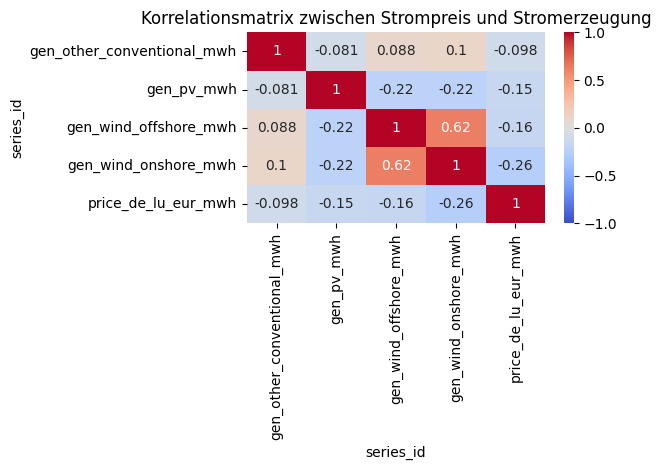

In [6]:
# plot correlation using heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_price_gen.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korrelationsmatrix zwischen Strompreis und Stromerzeugung')
plt.tight_layout()
plt.show()

Korrelationsmatrix zeigt negative Korrelation (z. B. Preis vs. PV), aber der Scatterplot für PV sieht nach einer leicht positiven Tendenz aus – ist in der Praxis häufig auf Ausreißer oder eine nichtlineare Verteilung zurückzuführen.

* ohne Ausreißer plotten


In [8]:
display(df_pivot.head())
print(df_pivot.columns)

series_id,gen_other_conventional_mwh,gen_pv_mwh,gen_wind_offshore_mwh,gen_wind_onshore_mwh,price_de_lu_eur_mwh
time_utc,,,,,
2026-05-19 22:00:00+00:00,1575.54,0.00,5176.04,9193.69,123.73
2026-05-19 23:00:00+00:00,1535.43,0.00,4501.08,9441.08,114.64
2026-05-20 00:00:00+00:00,1527.08,0.00,4502.38,9420.09,109.75
2026-05-20 01:00:00+00:00,1499.83,0.00,4747.88,9715.07,109.97
2026-05-20 02:00:00+00:00,1477.13,0.48,4928.60,10006.63,110.41


Index(['gen_other_conventional_mwh', 'gen_pv_mwh', 'gen_wind_offshore_mwh',
       'gen_wind_onshore_mwh', 'price_de_lu_eur_mwh'],
      dtype='str', name='series_id')


## Outlier analysis

* Identify outliers
    - Price limit < - 100 
        - Noon times in Apr, May (most) and Jul since 2023
    - RANSACRegressor. Try difference residual_threshold values emperically 
        - residual_threshold=700.0 
            - different times in Aug 2022 and Nov, Dec 2024
    - DBScan (eps=0.95)

* Handle outliers
    - Create time features: safe
    - Flag is_outlier: safe no information lost
    - Imputation: replacement nearest neighbour. Possibly distort data characters.
    - Remove: gaps in time series


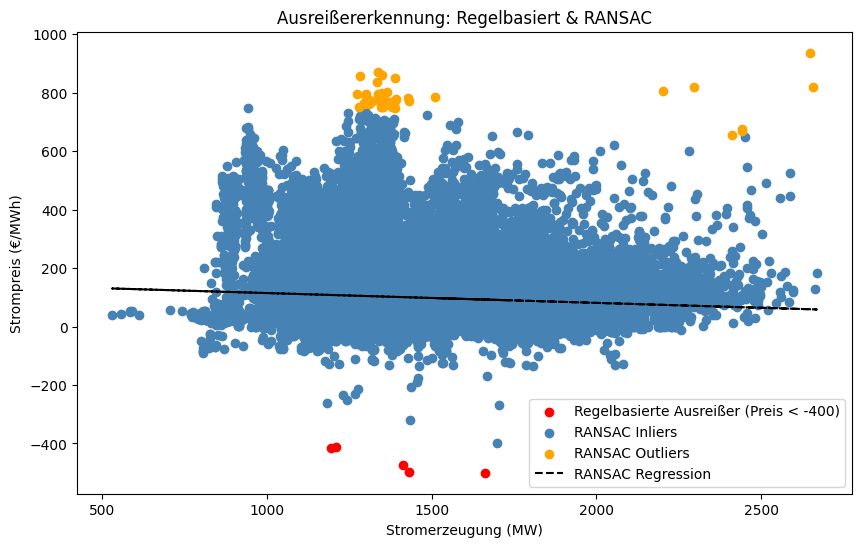

Regelbasierte Ausreißer: 5 / 64910
RANSAC-Inlier: 64863 / 64905 (ohne Regel-Ausreißer)
RANSAC-Ausreißer: 42 / 64905 (ohne Regel-Ausreißer)


In [5]:
# Kombinierte Ausreißer-Erkennung: Regelbasiert (Preis < -400) + RANSAC
from sklearn.linear_model import RANSACRegressor

df_pivot_subset = df_price_gen[['price_de_lu_eur_mwh', 'gen_other_conventional_mwh']].dropna()
# Regelbasierte Ausreißer
outlier_mask_rule = df_pivot_subset['price_de_lu_eur_mwh'] < -400
inlier_mask_rule = ~outlier_mask_rule

# RANSAC auf die regelbasierten Inlier anwenden
X = df_pivot_subset.loc[inlier_mask_rule, 'gen_other_conventional_mwh'].values.reshape(-1, 1)
y = df_pivot_subset.loc[inlier_mask_rule, 'price_de_lu_eur_mwh'].values
ransac = RANSACRegressor(residual_threshold=700.0, random_state=42)
ransac.fit(X, y)
inlier_mask_ransac = ransac.inlier_mask_
outlier_mask_ransac = ~inlier_mask_ransac

plt.figure(figsize=(10, 6))
# Regelbasierte Ausreißer (rot)
plt.scatter(df_pivot_subset.loc[outlier_mask_rule, 'gen_other_conventional_mwh'],
            df_pivot_subset.loc[outlier_mask_rule, 'price_de_lu_eur_mwh'],
            color='red', label='Regelbasierte Ausreißer (Preis < -400)')
# RANSAC-Inlier (blau)
plt.scatter(X[inlier_mask_ransac], y[inlier_mask_ransac], color='steelblue', label='RANSAC Inliers')
# RANSAC-Ausreißer (orange)
plt.scatter(X[outlier_mask_ransac], y[outlier_mask_ransac], color='orange', label='RANSAC Outliers')
# RANSAC-Regressionslinie
plt.plot(X, ransac.predict(X), color='black', linestyle='--', label='RANSAC Regression')
plt.xlabel('Stromerzeugung (MW)')
plt.ylabel('Strompreis (€/MWh)')
plt.title('Ausreißererkennung: Regelbasiert & RANSAC')
plt.legend()
plt.show()

print(f"Regelbasierte Ausreißer: {outlier_mask_rule.sum()} / {len(df_pivot_subset)}")
print(f"RANSAC-Inlier: {inlier_mask_ransac.sum()} / {len(X)} (ohne Regel-Ausreißer)")
print(f"RANSAC-Ausreißer: {outlier_mask_ransac.sum()} / {len(X)} (ohne Regel-Ausreißer)")

In [15]:
# read energy demand data from database and check the correlation with price
query = '''SELECT * 
    FROM energy_demand
    '''
df_demand = pd.read_sql(query, engine)
df_demand['time'] = pd.to_datetime(df_demand['time'], utc=True)

df_demand_price = pd.merge(df_demand, df_price_gen, left_on='time', right_index=True, how='inner')
df_demand_price = df_demand_price.drop('data_source', axis=1)
display(df_demand_price.head())


,time,energy_demand_mwh,smard_forecast_mwh,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio,is_workday,is_bridge_day,holiday_weight,is_pandemic_time,energy_demand_lag_24h,energy_demand_lag_168h,energy_demand_rolling_mean_24h,energy_demand_rolling_mean_168h,price_de_lu_eur_mwh,gen_other_conventional_mwh
0,2019-01-08 00:00:00+00:00,52754.4700,49815.00,2019,1,1,1,0,0,0.0,1,0,0.0,0,45312.4650,41653.9575,63820.062604,56515.537024,20.91,1499.50
1,2019-01-08 01:00:00+00:00,51889.2625,49241.75,2019,2,1,1,0,0,0.0,1,0,0.0,0,44833.5375,40113.5800,64130.146146,56581.611503,7.78,1489.00
2,2019-01-08 02:00:00+00:00,52475.5475,49512.25,2019,3,1,1,0,0,0.0,1,0,0.0,0,45508.9375,39312.9375,64424.134687,56651.704851,14.33,1501.25
3,2019-01-08 03:00:00+00:00,54096.5250,50572.75,2019,4,1,1,0,0,0.0,1,0,0.0,0,47355.7700,39097.1625,64714.410104,56730.053720,18.56,1538.00
4,2019-01-08 04:00:00+00:00,57487.6050,53273.00,2019,5,1,1,0,0,0.0,1,0,0.0,0,51699.4575,38634.3500,64995.274896,56819.335640,18.57,1573.00


## Outlieranalyse Fazit

* Regime A: Energiekrise 2022
    - hohe Preise
    - normaler Verbrauch
    - externe Marktfaktoren

* Regime B: Solarüberschuss 2024–2026
    - negative Preise
    - mittlere Last
    - hohe EE-Erzeugung

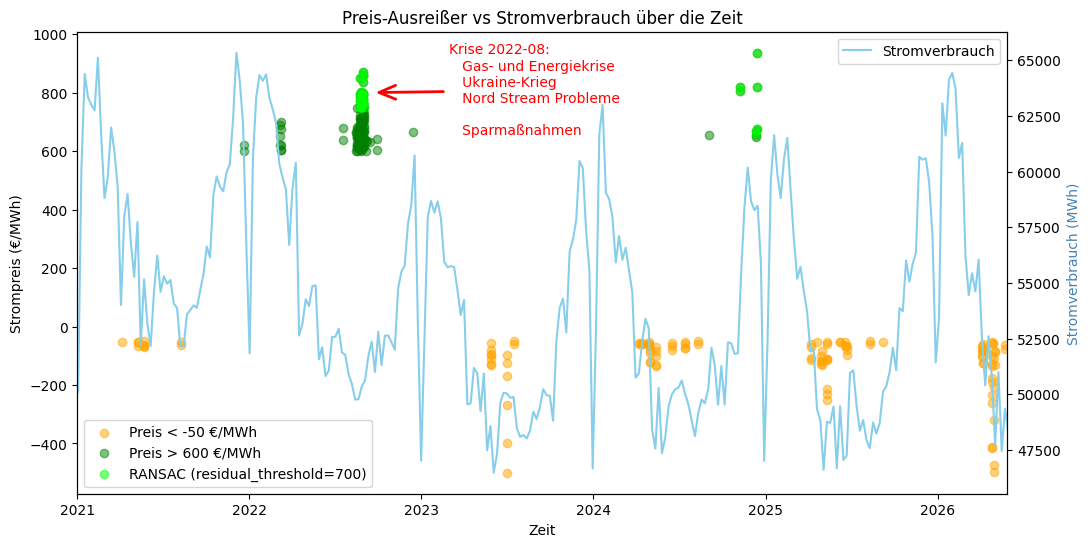

In [69]:
# outliers timely distributed?
import matplotlib.pyplot as plt 

df_price_gen = df_price_gen[['price_de_lu_eur_mwh', 'gen_other_conventional_mwh']].dropna()

df_demand_price_weekly = df_demand_price.set_index('time')
df_demand_price_weekly = df_demand_price_weekly.resample('W').mean(numeric_only=True)

outlier_lower_limit = -50
outlier_mask_lower_limit = df_price_gen['price_de_lu_eur_mwh'] < outlier_lower_limit
outlier_upper_limit = 600
outlier_mask_upper_limit = df_price_gen['price_de_lu_eur_mwh'] > outlier_upper_limit


# Zeitstempel der RANSAC-Ausreißer (nur auf die Regel-Inlier bezogen!)
index_inlier = df_price_gen.loc[inlier_mask_rule].index
index_ransac_outlier = index_inlier[outlier_mask_ransac]

fig, ax = plt.subplots(figsize=(12, 6))

# Lower limit Ausreißer (auf gesamtem df_price_gen)
ax.scatter(df_price_gen.index[outlier_mask_lower_limit], 
            df_price_gen.loc[outlier_mask_lower_limit, 'price_de_lu_eur_mwh'], 
            label=f'Preis < {outlier_lower_limit} €/MWh', color='orange', alpha=0.5)
# Upper limit Ausreißer (auf gesamtem df_price_gen)
ax.scatter(df_price_gen.index[outlier_mask_upper_limit], 
            df_price_gen.loc[outlier_mask_upper_limit, 'price_de_lu_eur_mwh'], 
            label=f'Preis > {outlier_upper_limit} €/MWh', color='green', alpha=0.5)
# RANSAC-Ausreißer (auf Zeitachse der Regel-Inlier)
ax.scatter(index_ransac_outlier, 
            df_price_gen.loc[index_ransac_outlier, 'price_de_lu_eur_mwh'], 
            label='RANSAC (residual_threshold=700)', color='lime', alpha=0.5)
# Line plot of energy demand
ax_twinx = ax.twinx()
ax_twinx.plot(df_demand_price_weekly.index, df_demand_price_weekly['energy_demand_mwh'], label='Stromverbrauch', color='skyblue')

ax.set_ylabel('Preis (€/MWh)')
ax_twinx.set_ylabel('Stromerzeugung (MW)', color='steelblue')
ax.set_xlabel('Zeit')
ax.set_ylabel('Strompreis (€/MWh)')
ax.annotate('Krise 2022-08:\n   Gas- und Energiekrise\n   Ukraine-Krieg\n   Nord Stream Probleme\n\n   Sparmaßnahmen', 
            xy=(pd.Timestamp('2022-09-20'), 800), xytext=(pd.Timestamp('2023-03-01'), 970),
            arrowprops=dict(arrowstyle='->,head_length=1.2,head_width=0.5', facecolor="red", edgecolor='red', linewidth=2), 
            fontsize=10, color= 'red', ha='left', va='top')
ax.legend(loc='lower left')
ax_twinx.legend(loc='upper right')
ax_twinx.set_ylabel('Stromverbrauch (MWh)')
start_2021 = pd.Timestamp('2021-01-01')
ax_twinx.set_xlim(start_2021, df_price_gen.index.max())

plt.title('Preis-Ausreißer vs Stromverbrauch über die Zeit')
plt.legend()
plt.show()


## Possible outlier - negative price timely distribution

* Weekend and holiday 
* Noon time in early summer

| Datum      | Uhrzeit UTC | Wochentag  | Möglicher Anlass         |
| ---------- | ----------- | ---------- | ------------------------ |
| 28.05.2023 | 11–12 Uhr   | Sonntag    | Pfingstsonntag           |
| 29.05.2023 |             | Montag     | Pfingstmontag (Feiertag) |
| 02.07.2023 | 10–14 Uhr   | Sonntag    | Wochenende               |
| 01.05.2024 | 11–12 Uhr   | Mittwoch   | Tag der Arbeit           |
| 12.05.2024 | 10–12 Uhr   | Sonntag    | Wochenende               |
| 06.04.2025 | 11–12 Uhr   | Sonntag    | Wochenende               |
| 27.04.2025 | 10–12 Uhr   | Sonntag    | Wochenende               |
| 01.05.2025 |             | Donnerstag | Tag der Arbeit           |
| 10.05.2025 |             | Samstag    | Wochenende               |
| 11.05.2025 | 10–13 Uhr   | Sonntag    | Wochenende               |
| 05.04.2026 |             | Sonntag    | Ostersonntag             |
| 06.04.2026 |             | Montag     | Ostermontag              |
| 25.04.2026 |             | Samstag    | Wochenende               |
| 26.04.2026 | 09–13 Uhr   | Sonntag    | Wochenende               |
| 01.05.2026 | 09–13 Uhr   | Freitag    | Tag der Arbeit           |
| 02.05.2026 |             | Samstag    | Wochenende               |

### Begründung

Industrieverbrauch ↓
Büroverbrauch ↓
PV-Erzeugung ↑
gleichzeitig.

Deutschland kann Strom nicht beliebig speichern.
Angebot > Nachfrage
muss Strom trotzdem ins Netz.

Dann zahlen Produzenten teilweise Geld dafür, dass ihnen jemand den Strom abnimmt.


In [ ]:
# print time slots of outliers

for year in range(2019, 2027):
    for month in range(1, 13):
        mask_month = (df_pivot_subset.index.year == year) & (df_pivot_subset.index.month == month)
        outliers_in_month = df_pivot_subset.loc[mask_month & outlier_mask_lower_limit]
        if not outliers_in_month.empty:
            print(f"\n{len(outliers_in_month)} Ausreißer (<{outlier_limit}) im {year}-{month:02d}:")
            print(outliers_in_month['price_de_lu_eur_mwh'])


3 Ausreißer (<-100) im 2023-05:
time
2023-05-28 11:00:00+00:00   -129.91
2023-05-28 12:00:00+00:00   -129.96
2023-05-29 12:00:00+00:00   -109.45
Name: price_de_lu_eur_mwh, dtype: float64

5 Ausreißer (<-100) im 2023-07:
time
2023-07-02 10:00:00+00:00   -167.96
2023-07-02 11:00:00+00:00   -266.92
2023-07-02 12:00:00+00:00   -500.00
2023-07-02 13:00:00+00:00   -399.00
2023-07-02 14:00:00+00:00   -124.21
Name: price_de_lu_eur_mwh, dtype: float64

5 Ausreißer (<-100) im 2024-05:
time
2024-05-01 11:00:00+00:00   -120.00
2024-05-01 12:00:00+00:00   -120.07
2024-05-12 10:00:00+00:00   -100.06
2024-05-12 11:00:00+00:00   -135.45
2024-05-12 12:00:00+00:00   -132.85
Name: price_de_lu_eur_mwh, dtype: float64

5 Ausreißer (<-100) im 2025-04:
time
2025-04-06 11:00:00+00:00   -106.31
2025-04-06 12:00:00+00:00   -114.57
2025-04-27 10:00:00+00:00   -101.04
2025-04-27 11:00:00+00:00   -129.81
2025-04-27 12:00:00+00:00   -116.61
Name: price_de_lu_eur_mwh, dtype: float64

8 Ausreißer (<-100) im 2025-05:

In [ ]:
# print time slots of RANSAC outliers
for year in range(2019, 2027):
    for month in range(1, 13):
        mask_month = (index_ransac_outlier.year == year) & (index_ransac_outlier.month == month)
        outliers_in_month = df_pivot_subset.loc[index_ransac_outlier[mask_month], 'price_de_lu_eur_mwh']
        if not outliers_in_month.empty:
            print(f"\n{len(outliers_in_month)} RANSAC-Ausreißer im {year}-{month:02d}:")
            print(outliers_in_month)


35 RANSAC-Ausreißer im 2022-08:
time
2022-08-23 17:00:00+00:00    794.95
2022-08-23 18:00:00+00:00    771.00
2022-08-24 16:00:00+00:00    750.00
2022-08-24 17:00:00+00:00    850.00
2022-08-24 18:00:00+00:00    783.56
2022-08-25 17:00:00+00:00    766.79
2022-08-25 18:00:00+00:00    760.00
2022-08-26 04:00:00+00:00    750.00
2022-08-26 05:00:00+00:00    769.23
2022-08-26 06:00:00+00:00    802.99
2022-08-26 07:00:00+00:00    781.62
2022-08-26 08:00:00+00:00    763.20
2022-08-26 09:00:00+00:00    750.03
2022-08-26 15:00:00+00:00    750.01
2022-08-26 16:00:00+00:00    770.00
2022-08-26 17:00:00+00:00    780.00
2022-08-26 18:00:00+00:00    778.54
2022-08-26 19:00:00+00:00    770.00
2022-08-26 20:00:00+00:00    747.74
2022-08-29 05:00:00+00:00    769.92
2022-08-29 06:00:00+00:00    793.99
2022-08-29 15:00:00+00:00    773.91
2022-08-29 16:00:00+00:00    837.66
2022-08-29 17:00:00+00:00    871.00
2022-08-29 18:00:00+00:00    860.89
2022-08-29 19:00:00+00:00    800.00
2022-08-29 20:00:00+00:00 

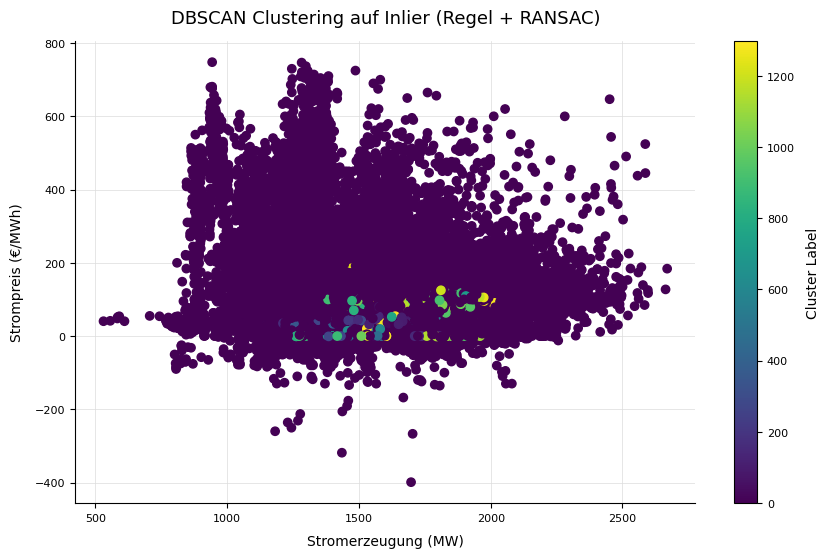

DBSCAN Cluster Labels: [  -1    0    1 ... 1296 1297 1298]
Anzahl Noise-Punkte (Label -1): 53184 / 64863


In [71]:
# DBSCAN-Ausreißererkennung ergänzend zu Regel + RANSAC
from sklearn.cluster import DBSCAN

# Nur die regelbasierten und RANSAC-Inlier verwenden
df_inlier = df_pivot_subset.loc[inlier_mask_rule].iloc[inlier_mask_ransac]
X_dbscan = df_inlier[['gen_other_conventional_mwh', 'price_de_lu_eur_mwh']].values
dbscan = DBSCAN(eps=0.95, min_samples=5)
labels = dbscan.fit_predict(X_dbscan)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_inlier['gen_other_conventional_mwh'], df_inlier['price_de_lu_eur_mwh'], c=labels, cmap='viridis', label='DBSCAN Cluster')
plt.xlabel('Stromerzeugung (MW)')
plt.ylabel('Strompreis (€/MWh)')
plt.title('DBSCAN Clustering auf Inlier (Regel + RANSAC)')
plt.colorbar(scatter, label='Cluster Label')
plt.show()

print(f"DBSCAN Cluster Labels: {np.unique(labels)}")
print(f"Anzahl Noise-Punkte (Label -1): {(labels==-1).sum()} / {len(labels)}")

## Time series decomposition

* additive model - seasonal values and redisual independent on trend
* in case of linear trend

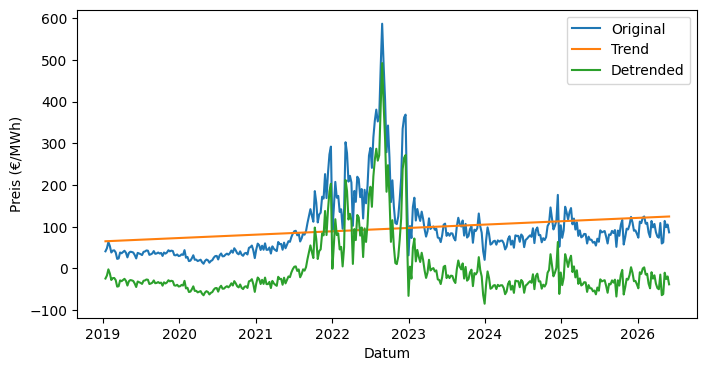

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


x = mdates.date2num(df_demand_price_weekly.index)
y = df_demand_price_weekly['price_de_lu_eur_mwh'].values

slope, intercept = np.polyfit(x, y, 1) # estimate line coefficient
trend = x * slope + intercept # linear trend
detrended = y - trend # remove the trend

plt.figure(figsize=(8, 4))
plt.plot(df_demand_price_weekly.index, df_demand_price_weekly['price_de_lu_eur_mwh'], label='Original')
plt.plot(df_demand_price_weekly.index, trend, label='Trend')
plt.plot(df_demand_price_weekly.index, detrended, label='Detrended')
plt.legend()
plt.xlabel('Datum')
plt.ylabel('Preis (€/MWh)')
plt.show()

### Time series decomposition - additive vs multiplicative

* clear seasonal/yearly pattern
* trend - long-term development 

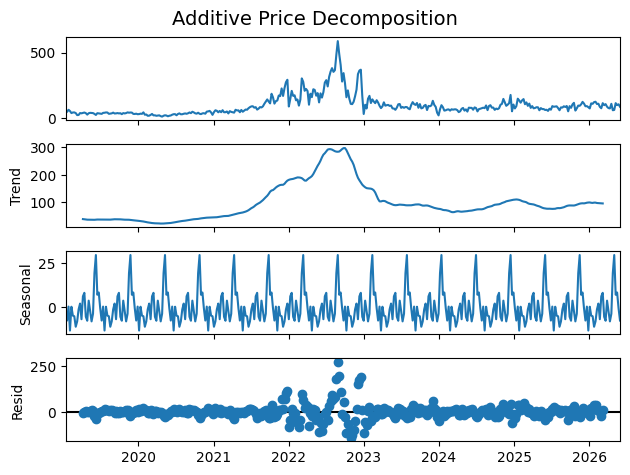

In [72]:
# decompose seasonality using seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose     
#df_monthly.set_index('DateUTC', inplace=True)
decomposition = seasonal_decompose(df_demand_price_weekly['price_de_lu_eur_mwh'], model='additive', period=24) # hourly data, so period is 24 hours
fig = decomposition.plot()
fig.suptitle('Additive Price Decomposition', fontsize=14)
fig.axes[0].set_title("") 
plt.show();

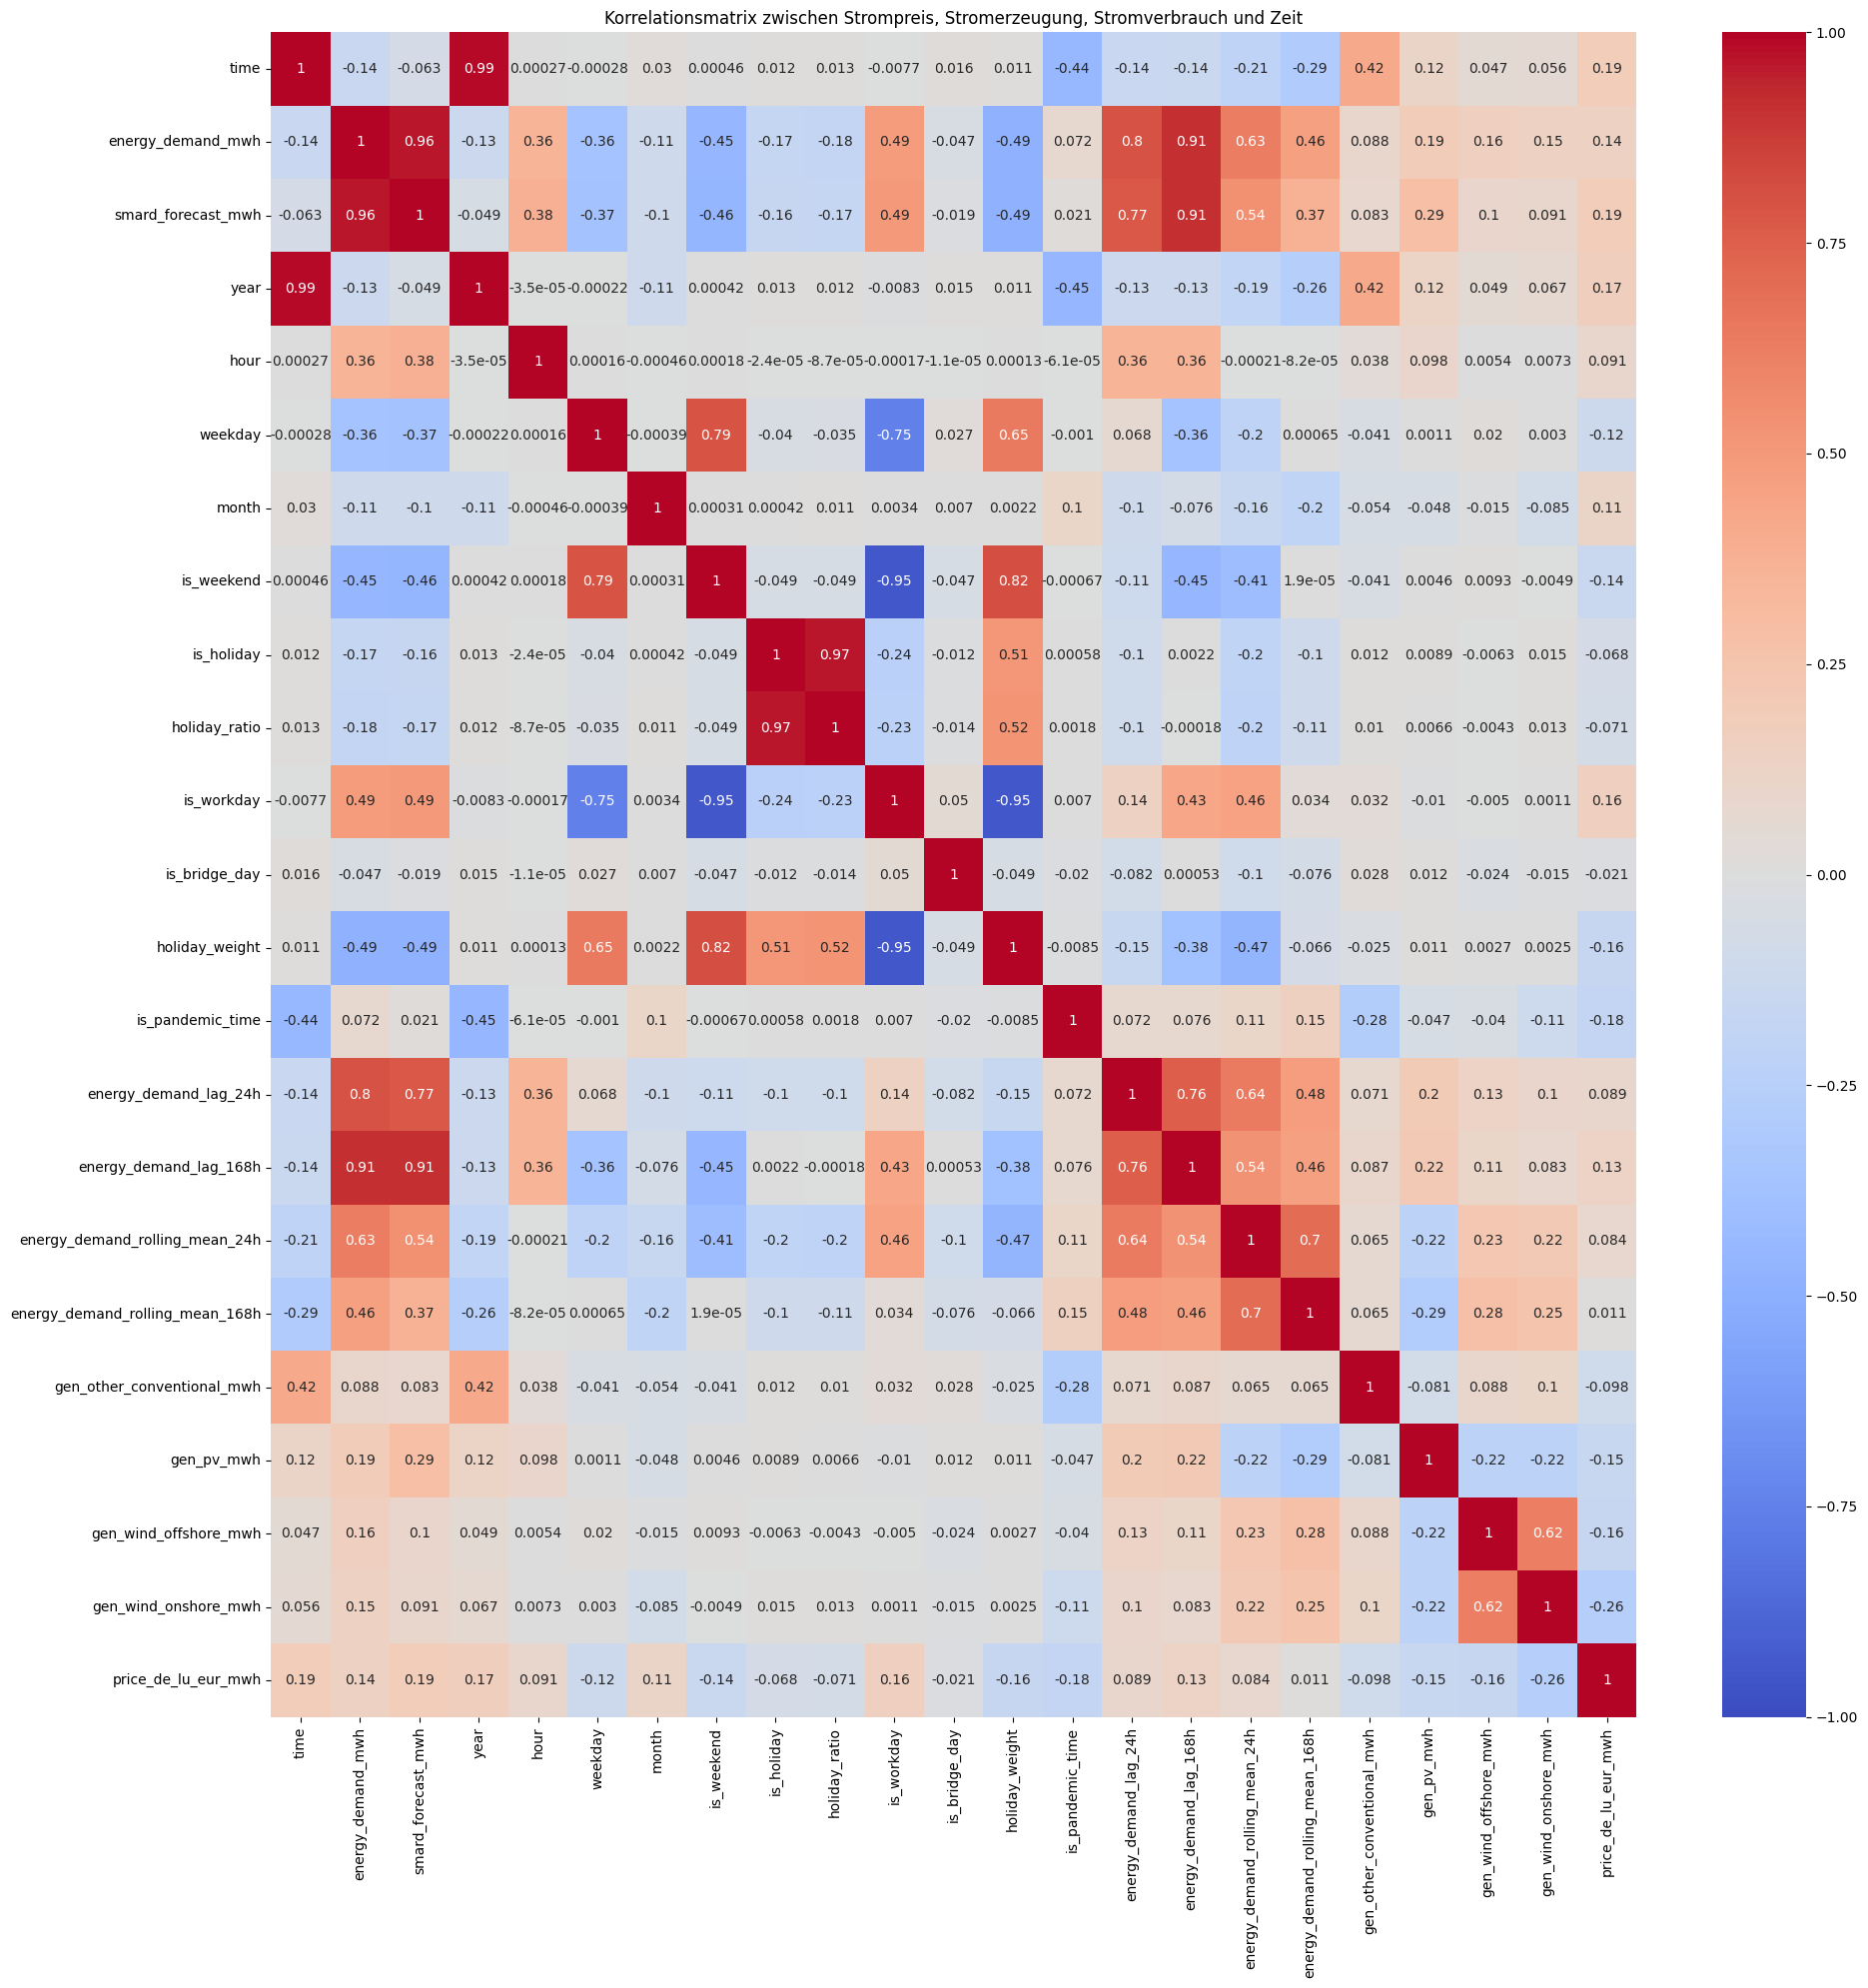

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(df_demand_price.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Korrelationsmatrix zwischen Strompreis, Stromerzeugung, Stromverbrauch und Zeit')
plt.tight_layout()
plt.show()

In [15]:
# update database with new data
from etl_price import update_database

update_database(start_date='2019-01-01', end_date='2026-05-27')

engine = sa.create_engine('sqlite:///../db/energy_demand.db')
inpector = sa.inspect(engine)
table_names = inpector.get_table_names()
for table in table_names:
    print(f"Columns in {table}: {[col['name'] for col in inpector.get_columns(table)]}")

Series catalog seeded/updated rows: 5

Current price data status:
  price_de_lu_eur_mwh      :    216 rows | max: 2026-05-28T21:00:00Z
  gen_wind_onshore_mwh     :    207 rows | max: 2026-05-28T12:00:00Z
  gen_wind_offshore_mwh    :    207 rows | max: 2026-05-28T12:00:00Z
  gen_pv_mwh               :    207 rows | max: 2026-05-28T12:00:00Z
  gen_other_conventional_mwh:    207 rows | max: 2026-05-28T12:00:00Z

Fetching and storing SMARD price/generation series: 2019-01-01 → 2026-05-27
Batch ingestion result: {'run_id': 3, 'status': 'success', 'total_inserted': 323515, 'per_series': {'price_de_lu_eur_mwh': 64703, 'gen_wind_onshore_mwh': 64703, 'gen_wind_offshore_mwh': 64703, 'gen_pv_mwh': 64703, 'gen_other_conventional_mwh': 64703}, 'errors': {}}

Done.
  price_de_lu_eur_mwh      :  64919 rows | max: 2026-05-28T21:00:00Z
  gen_wind_onshore_mwh     :  64910 rows | max: 2026-05-28T12:00:00Z
  gen_wind_offshore_mwh    :  64910 rows | max: 2026-05-28T12:00:00Z
  gen_pv_mwh               :  6

### Distribution on different time features

* is_weekend, is_holiday, is_bridge_day distribution
* Weekday, week, month distribution

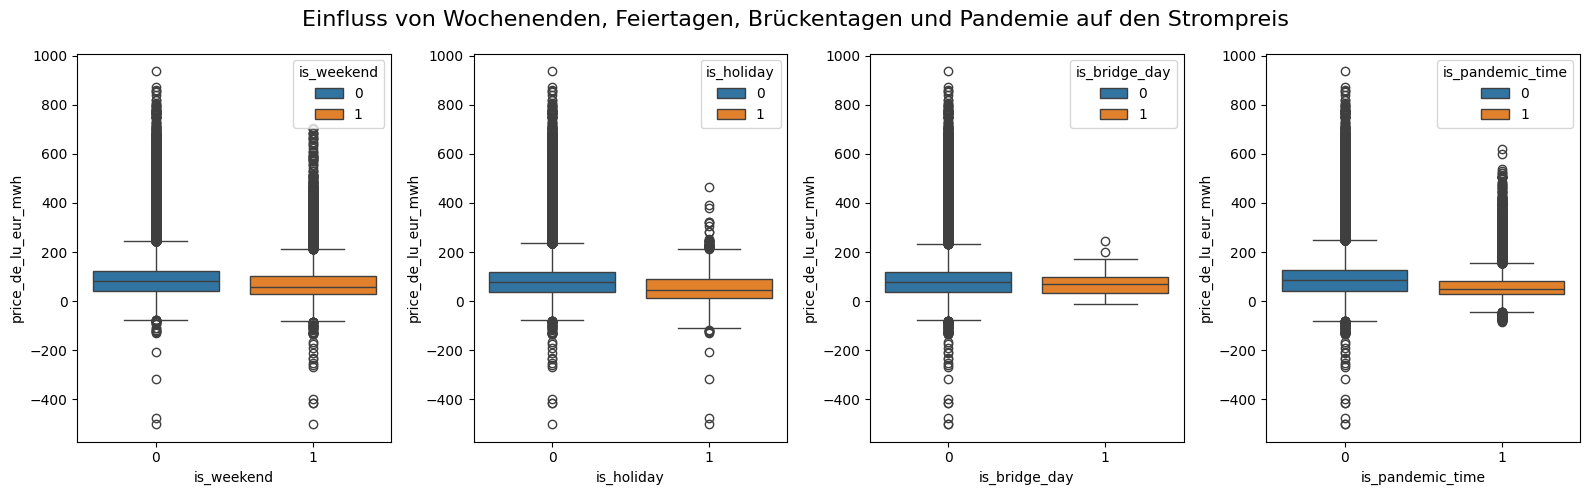

In [13]:
# plot weekend, holiday effects
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# boxplot for weekend, holiday effects
plt.figure(figsize=(16, 5))
plt.subplot(1, 4, 1)
sns.boxplot(x='is_weekend', y='price_de_lu_eur_mwh', hue='is_weekend', data=df_demand_price)
#plt.title('Weekend vs Weekday')
plt.subplot(1, 4, 2)
sns.boxplot(x='is_holiday', y='price_de_lu_eur_mwh', hue='is_holiday', data=df_demand_price)
#plt.title('Holiday vs Non-Holiday')
plt.subplot(1, 4, 3)
sns.boxplot(x='is_bridge_day', y='price_de_lu_eur_mwh', hue='is_bridge_day', data=df_demand_price)
#plt.title('Bridge Day vs Non-Bridge Day')
plt.subplot(1, 4, 4)
sns.boxplot(x='is_pandemic_time', y='price_de_lu_eur_mwh', hue='is_pandemic_time', data=df_demand_price)
#plt.title('Pandemic vs Non-Pandemic')
#plt.gca().legend(loc='lower right')

plt.suptitle('Einfluss von Wochenenden, Feiertagen, Brückentagen und Pandemie auf den Strompreis', fontsize=16)

plt.tight_layout()
plt.show()



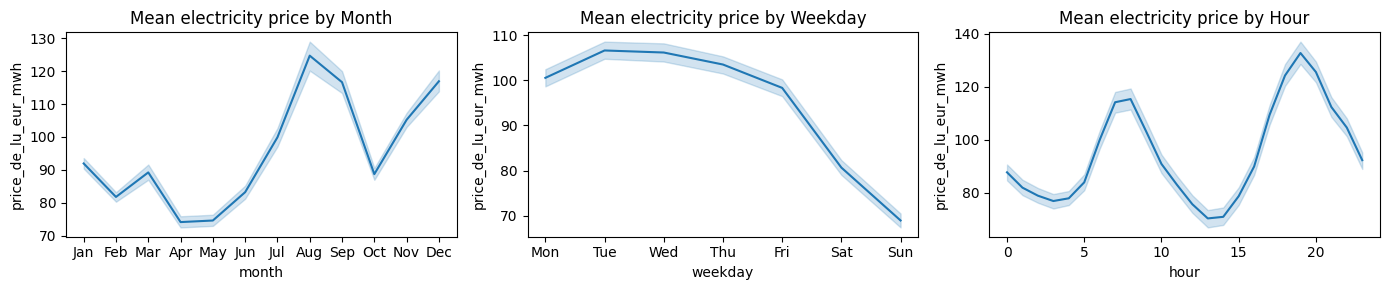

In [14]:
# plot mean energy demand by month, weekday, hour
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#df_energy_de = pd.read_csv("../data/processed/energy_demand_de_2019_2025.csv", parse_dates=['DateUTC'])

plt.figure(figsize=(14, 3))
# rename x-axis labels for better readability
df_demand_price['month'] = df_demand_price['month'].map({1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'})
df_demand_price['weekday'] = df_demand_price['weekday'].map({0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'})  
# sort the weekday order
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_demand_price['weekday'] = pd.Categorical(df_demand_price['weekday'], categories=weekday_order, ordered=True) 

plt.subplot(1, 3, 1)
sns.lineplot(x='month', y='price_de_lu_eur_mwh', data=df_demand_price)
plt.title('Mean electricity price by Month')    
plt.subplot(1, 3, 2)
sns.lineplot(x='weekday', y='price_de_lu_eur_mwh', data=df_demand_price)
plt.title('Mean electricity price by Weekday')
plt.subplot(1, 3, 3)
sns.lineplot(x='hour', y='price_de_lu_eur_mwh', data=df_demand_price)
plt.title('Mean electricity price by Hour')
plt.tight_layout()
plt.show()